In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, f1_score
from sklearn.exceptions import ConvergenceWarning
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

df = pd.read_csv('./american_bankruptcy.csv')
df.head()

C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [2]:
# Pre-processing
df['status_label'] = df['status_label'].map({'alive': 1, 'failed': 0})
X_pre = df.drop(columns=['company_name', 'status_label'])
y_pre = df['status_label']
df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,1,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,1,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,1,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,1,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,1,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [5]:
def select_features_for_ml(X_train,y_train, df_analysis, model):

    print("Selecting features to train " + model + " model")
    if model == 'Random Forest':
        #Selected Features Using Random Forest:  ['X8', 'X15', 'X3', 'X1', 'X17', 'X7', 'X13', 'X10', 'X6', 'X14']
        selected_features = ['X8', 'X15', 'X3', 'X1', 'X17', 'X7', 'X13', 'X10', 'X6', 'X14']
        """

        # Random Forest or Decision Tree feature selection
        model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
        model_rf.fit(X_train, y_train)

        feature_importance_rf = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": model_rf.feature_importances_
        }).sort_values(by="Importance", ascending=False)
        selected_features = feature_importance_rf['Feature'].head(10).tolist()
        """
        df_selected = df_analysis[['company_name', 'status_label'] + selected_features]
        df_selected.to_csv('rf_selected_features_test_dataset.csv', index=False)
        print("Datasets saved to CSV files.")

    elif model == 'XGBoost':
        # Selected Features Using XGBoost:  ['year', 'X8', 'X1', 'X11', 'X10', 'X3', 'X18', 'X15', 'X5', 'X2']
        selected_features = ['year', 'X8', 'X1', 'X11', 'X10', 'X3', 'X18', 'X15', 'X5', 'X2']
        """
        # XGB feature selection
        model_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42)
        model_xgb.fit(X_train, y_train)

        explainer = shap.Explainer(model_xgb, X_train)
        shap_values = explainer(X_train)

        # Get Mean Absolute SHAP Values for Each Feature
        shap_importance = pd.DataFrame({
            "Feature": X_train.columns,
            "SHAP Importance": abs(shap_values.values).mean(axis=0)
        }).sort_values(by="SHAP Importance", ascending=False)

        # Sort by Importance and Select Top 10 Features
        selected_features = shap_importance['Feature'].head(10).tolist()
        """
        df_selected = df_analysis[['company_name', 'status_label'] + selected_features]
        df_selected.to_csv('xgb_selected_features_test_dataset.csv', index=False)
        print("Datasets saved to CSV files.")

        #shap.summary_plot(shap_values, X_train)
        df_selected = df_analysis[['company_name', 'status_label'] + selected_features]

    elif model == 'Gradient Boosting':
        # Selected Features Using Gradient Boosting:  ['X15', 'X8', 'X5', 'X3', 'year', 'X7', 'X13', 'X2', 'X11', 'X1']
        selected_features = ['X15', 'X8', 'X5', 'X3', 'year', 'X7', 'X13', 'X2', 'X11', 'X1']
        """

        # Gradient Boosting feature selection
        model_gb = LGBMClassifier(n_estimators=100, random_state=42,verbosity=-1)
        model_gb.fit(X_train, y_train)

        feature_importance_gb = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": model_gb.feature_importances_
        }).sort_values(by="Importance", ascending=False)

        selected_features = feature_importance_gb['Feature'].head(10).tolist()
        """
        df_selected = df_analysis[['company_name', 'status_label'] + selected_features]
        df_selected.to_csv('gb_selected_features_test_dataset.csv', index=False)
        print("Datasets saved to CSV files.")

    return selected_features, df_selected

selected_features_rf, df_rf = select_features_for_ml(X_pre, y_pre, df, 'Random Forest')
selected_features_gb, df_gb = select_features_for_ml(X_pre, y_pre, df, 'Gradient Boosting')
selected_features_xgb, df_xgb = select_features_for_ml(X_pre, y_pre, df, 'XGBoost')

Selecting features to train Random Forest model
Datasets saved to CSV files.
Selecting features to train Gradient Boosting model
Datasets saved to CSV files.
Selecting features to train XGBoost model
Datasets saved to CSV files.


In [6]:
def plot_confusion_matrix(ax, cm, method_name):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5, square=True, ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(method_name + ' Confusion Matrix')

def plot_roc_auc_curve(ax, fpr, tpr, roc_auc, method_name):
    ax.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(method_name + ' ROC Curve')
    ax.legend(loc="lower right")
    ax.grid(True)

def plot_precision_recall(ax, recall, precision, method_name):
    ax.plot(recall, precision, color='blue', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(method_name + ' Precision-Recall Curve')
    ax.grid(True)

def plot_all_metrics(cm, fpr, tpr, roc_auc, recall, precision, method_name):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Adjust figsize as needed

    plot_confusion_matrix(axs[0], cm, method_name)
    plot_roc_auc_curve(axs[1], fpr, tpr, roc_auc, method_name)
    plot_precision_recall(axs[2], recall, precision, method_name)

    plt.tight_layout()  # Adjust spacing
    plt.show()

## **📈 Random Forest**  
- A tree-based ensemble method that uses Gini impurity to assess feature importance.

Random Forest Accuracy: 93.51%
Confusion Matrix:
[[   54  1014]
 [    7 14662]]
Classification Report:
              precision    recall  f1-score   support

           0    0.88525   0.05056   0.09566      1068
           1    0.93532   0.99952   0.96635     14669

    accuracy                        0.93512     15737
   macro avg    0.91028   0.52504   0.53101     15737
weighted avg    0.93192   0.93512   0.90726     15737


Cross-Validation Scores:
Fold 1: 93.29%
Fold 2: 93.21%
Fold 3: 93.17%
Fold 4: 93.15%
Fold 5: 93.39%
Average Cross-Validation Score: 93.24%


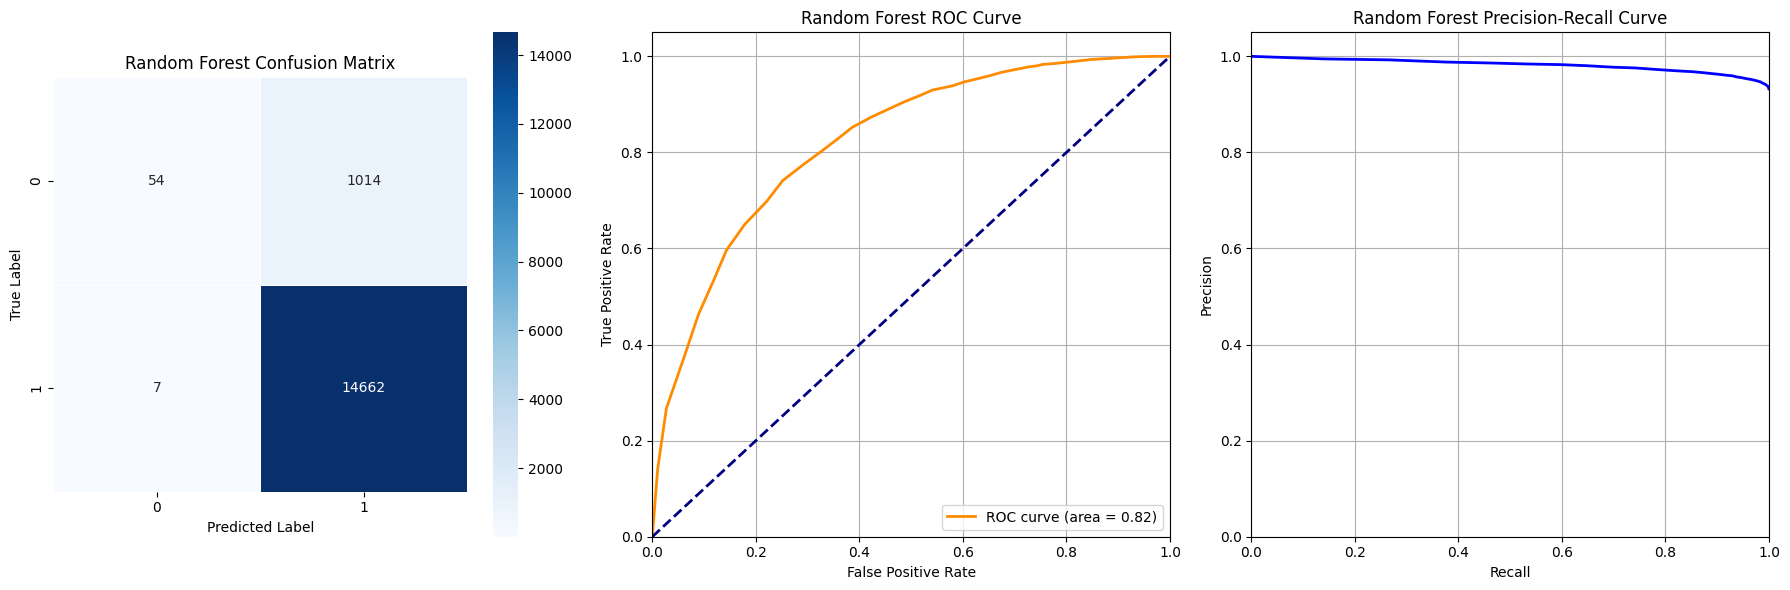

In [7]:
def rf_classify(df_classify):
    # RandomForestClassifier
    X = df_classify.drop(columns=['company_name', 'status_label'], axis=1)
    y = df_classify['status_label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Random Forest Accuracy: {:.2f}%".format(accuracy * 100))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Classification Report
    cr = classification_report(y_test, y_pred, digits=5)
    print("Classification Report:")
    print(cr)

    # ROC Curve and AUC-ROC
    y_scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall Curve
    precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)

    #Cross-Validation Scores
    cv_scores = cross_val_score(model, X, y, cv=5)
    print("\nCross-Validation Scores:")
    for i, score in enumerate(cv_scores):
        print("Fold {}: {:.2f}%".format(i + 1, score * 100))

    # Average Cross-Validation Score
    average_cv_score = cv_scores.mean()
    print("Average Cross-Validation Score: {:.2f}%".format(average_cv_score * 100))

    # Calculate F1 Score for SVM
    f1_score_rf = f1_score(y_test, y_pred)

    # Plot and save confusion matrix, ROC-AUC curve, precision-recall
    plot_all_metrics(cm, fpr, tpr, roc_auc, recall, precision, 'Random Forest')

    return roc_auc, accuracy, model, average_cv_score, f1_score_rf

rf_roc_auc, rf_accuracy, rf_model, rf_avg_cv_score, rf_f1_score = rf_classify(df_rf)

## **📈 Random Forest**  
- A tree-based ensemble method that uses Gini impurity to assess feature importance.

Random Forest Accuracy: 93.51%
Confusion Matrix:
[[   54  1014]
 [    7 14662]]
Classification Report:
              precision    recall  f1-score   support

           0    0.88525   0.05056   0.09566      1068
           1    0.93532   0.99952   0.96635     14669

    accuracy                        0.93512     15737
   macro avg    0.91028   0.52504   0.53101     15737
weighted avg    0.93192   0.93512   0.90726     15737


Cross-Validation Scores:
Fold 1: 93.29%
Fold 2: 93.21%
Fold 3: 93.17%
Fold 4: 93.15%
Fold 5: 93.39%
Average Cross-Validation Score: 93.24%


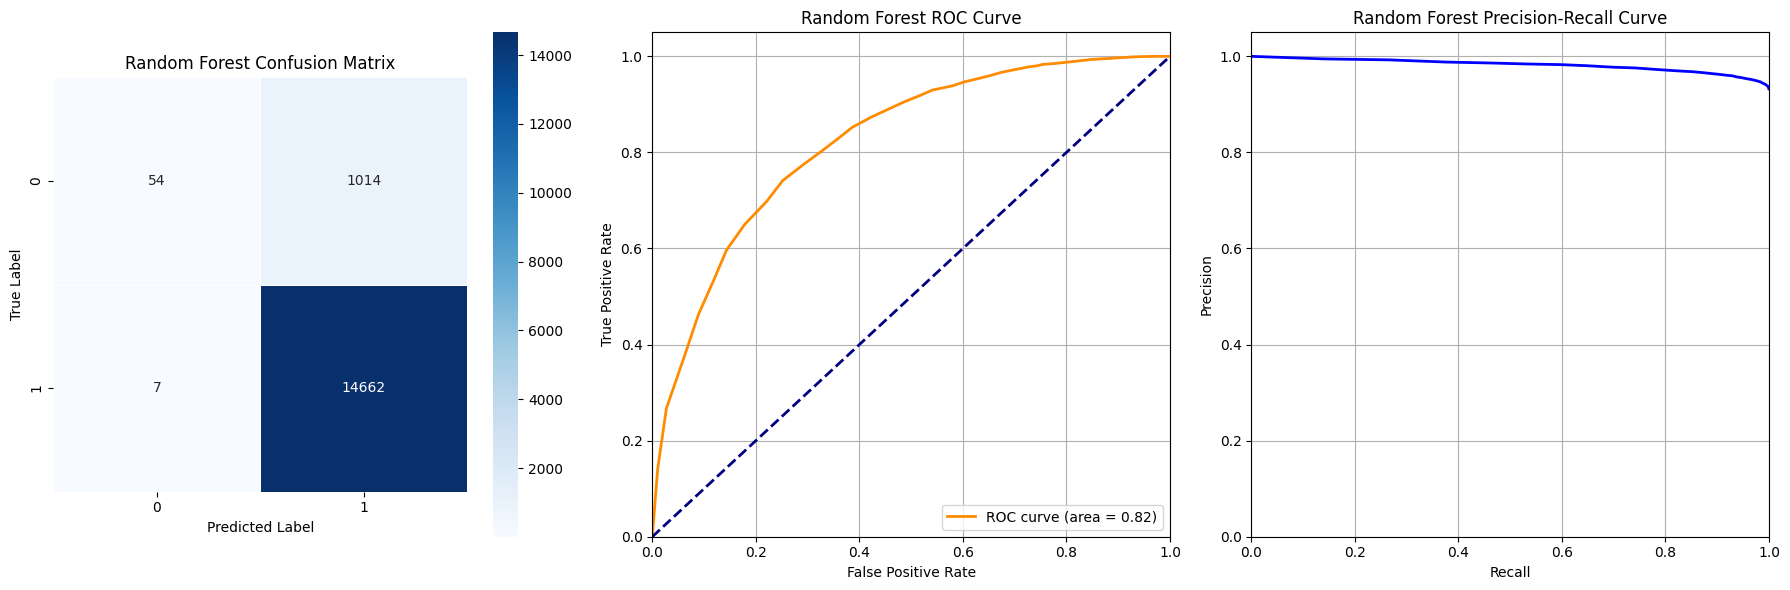

In [8]:
def rf_classify(df_classify):
    # RandomForestClassifier
    X = df_classify.drop(columns=['company_name', 'status_label'], axis=1)
    y = df_classify['status_label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Random Forest Accuracy: {:.2f}%".format(accuracy * 100))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Classification Report
    cr = classification_report(y_test, y_pred, digits=5)
    print("Classification Report:")
    print(cr)

    # ROC Curve and AUC-ROC
    y_scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall Curve
    precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)

    #Cross-Validation Scores
    cv_scores = cross_val_score(model, X, y, cv=5)
    print("\nCross-Validation Scores:")
    for i, score in enumerate(cv_scores):
        print("Fold {}: {:.2f}%".format(i + 1, score * 100))

    # Average Cross-Validation Score
    average_cv_score = cv_scores.mean()
    print("Average Cross-Validation Score: {:.2f}%".format(average_cv_score * 100))

    # Calculate F1 Score for SVM
    f1_score_rf = f1_score(y_test, y_pred)

    # Plot and save confusion matrix, ROC-AUC curve, precision-recall
    plot_all_metrics(cm, fpr, tpr, roc_auc, recall, precision, 'Random Forest')

    return roc_auc, accuracy, model, average_cv_score, f1_score_rf

rf_roc_auc, rf_accuracy, rf_model, rf_avg_cv_score, rf_f1_score = rf_classify(df_rf)

## **📈 Grandient Boosting (LGBMClassifier)**  
- An efficient boosting method that ranks features using built-in importance scores from LightGBM.

Gradient Boosting Accuracy: 93.45%
Confusion Matrix:
[[   23  1021]
 [   10 14683]]
Classification Report:
              precision    recall  f1-score   support

           0    0.69697   0.02203   0.04271      1044
           1    0.93498   0.99932   0.96608     14693

    accuracy                        0.93449     15737
   macro avg    0.81598   0.51068   0.50440     15737
weighted avg    0.91919   0.93449   0.90483     15737



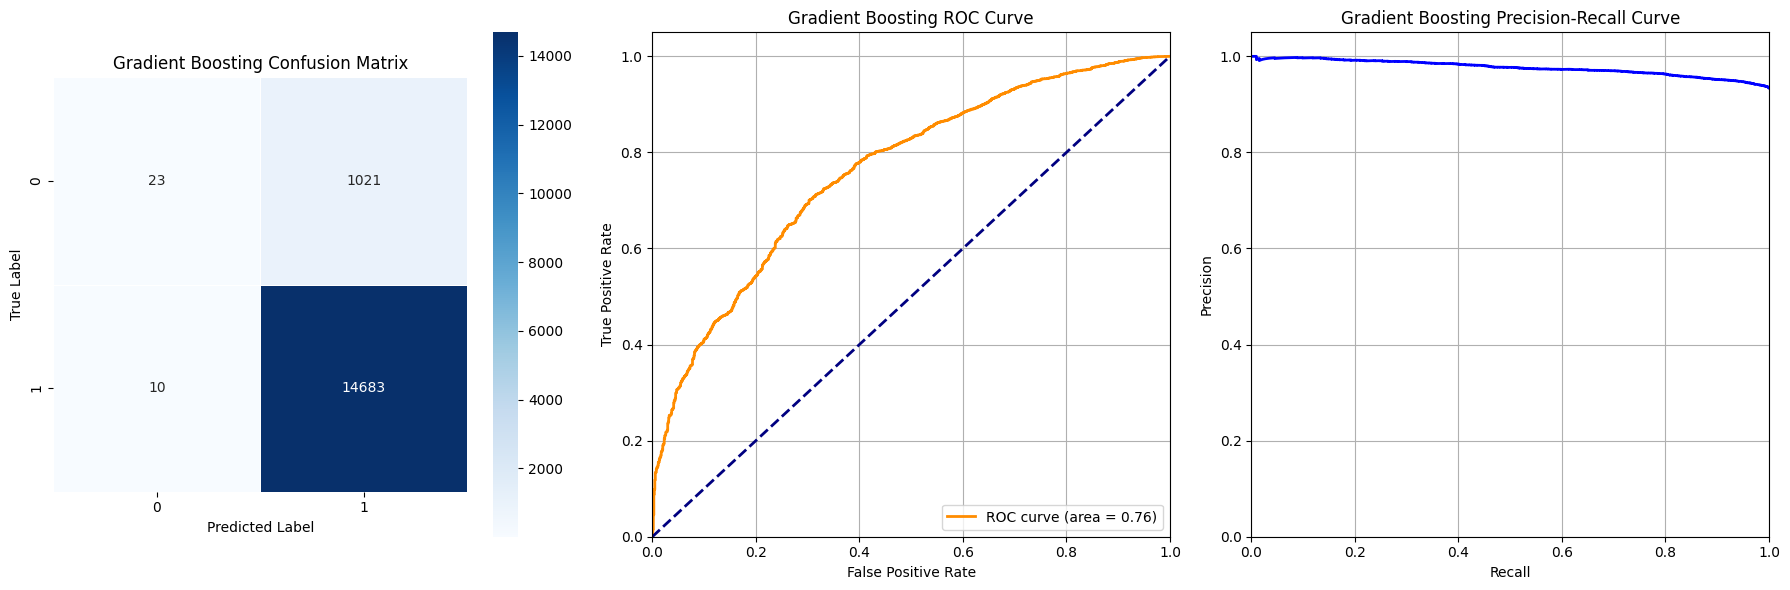

In [9]:
def grad_boosting_classify(df_classify):
    # GradientBoostingClassifier
    X = df_classify.drop(columns=['company_name', 'status_label'], axis=1)
    y = df_classify['status_label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Gradient Boosting Accuracy: {:.2f}%".format(accuracy * 100))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Classification Report
    cr = classification_report(y_test, y_pred, digits=5)
    print("Classification Report:")
    print(cr)

    y_scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall Curve
    precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)

    # Calculate Cross-Validation Scores for Gradient Boosting
    cv_scores = cross_val_score(model, X, y, cv=5)
    average_cv_score = cv_scores.mean()

    # Calculate F1 Score for Gradient Boosting
    f1_score_gb = f1_score(y_test, y_pred)

    # Plot and save confusion matrix, ROC-AUC curve, precision-recall
    plot_all_metrics(cm, fpr, tpr, roc_auc, recall, precision, 'Gradient Boosting')

    return roc_auc, accuracy, model, average_cv_score, f1_score_gb

gb_roc_auc, gb_accuracy, gb_model, gb_avg_cv_score, gb_f1_score = grad_boosting_classify(df_gb)

## **📈 XGBoost (SHAP Analysis)**  
- A powerful gradient boosting model that utilizes SHAP values for interpretable feature contributions.

XGBoost Accuracy: 93.73%
Confusion Matrix:
[[  126   942]
 [   45 14624]]
Classification Report:
              precision    recall  f1-score   support

           0    0.73684   0.11798   0.20339      1068
           1    0.93948   0.99693   0.96736     14669

    accuracy                        0.93728     15737
   macro avg    0.83816   0.55745   0.58537     15737
weighted avg    0.92573   0.93728   0.91551     15737


Cross-Validation Scores:
Fold 1: 93.33%
Fold 2: 93.32%
Fold 3: 92.41%
Fold 4: 92.65%
Fold 5: 93.17%
Average Cross-Validation Score: 92.98%


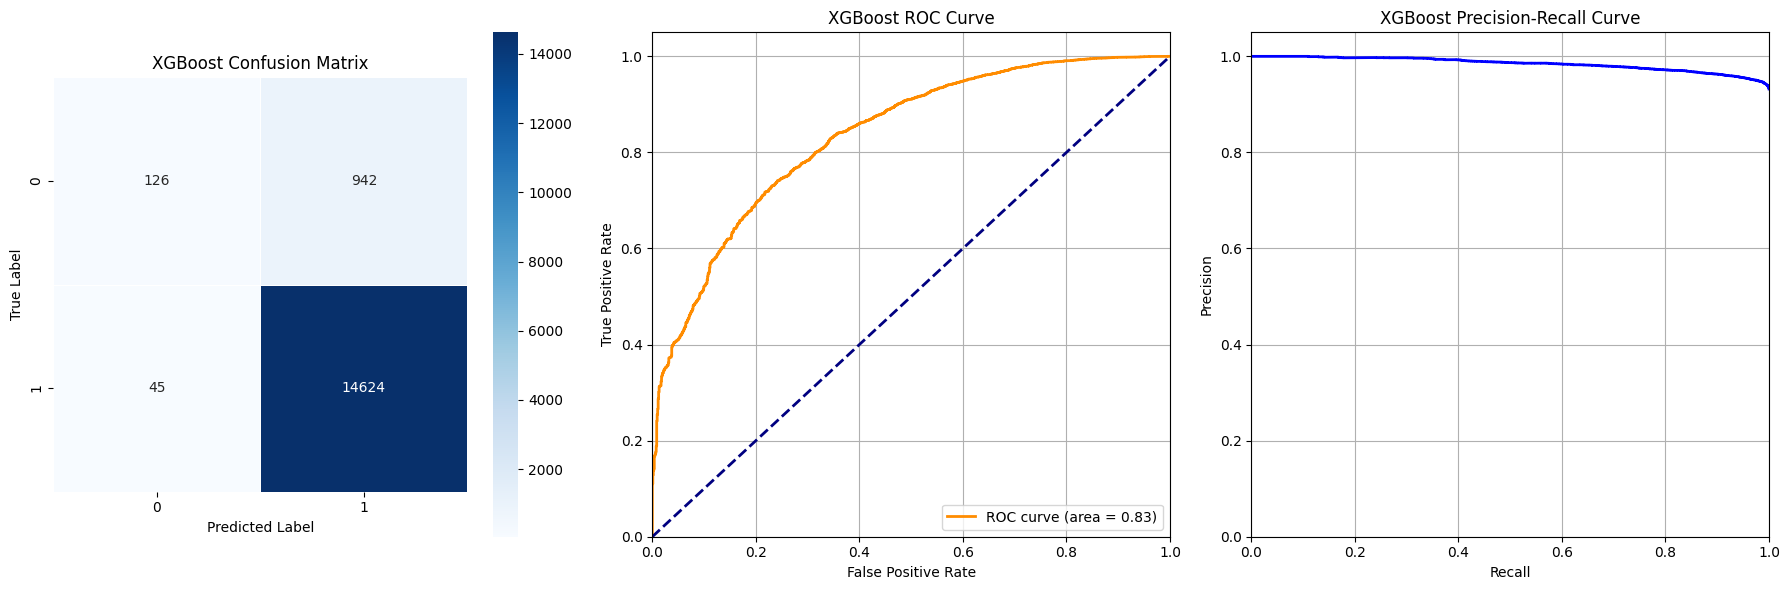

In [10]:
def xgboost_classify(df_classify):

    # Splitting the data
    X = df_classify.drop(columns=['company_name', 'status_label'], axis=1)
    y = df_classify['status_label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # XGB feature selection
    model = xgb.XGBClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("XGBoost Accuracy: {:.2f}%".format(accuracy * 100))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Classification Report
    cr = classification_report(y_test, y_pred, digits=5)
    print("Classification Report:")
    print(cr)

    # ROC Curve and AUC-ROC
    y_scores = model.predict_proba(X_test)[:, 1]
    fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr_xgb, tpr_xgb)

    # Precision-Recall Curve
    precision_xgb, recall_xgb, thresholds_pr_xgb = precision_recall_curve(y_test, y_scores)

    # Cross-Validation Scores
    cv_scores_xgb = cross_val_score(model, X, y, cv=5)
    print("\nCross-Validation Scores:")
    for i, score in enumerate(cv_scores_xgb):
        print("Fold {}: {:.2f}%".format(i + 1, score * 100))

    # Average Cross-Validation Score
    average_cv_score = cv_scores_xgb.mean()
    print("Average Cross-Validation Score: {:.2f}%".format(average_cv_score * 100))

    y_scores = model.predict_proba(X_test)[:, 1]
    fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr_xgb, tpr_xgb)

    # Precision-Recall Curve
    precision_xgb, recall_xgb, thresholds_pr_xgb = precision_recall_curve(y_test, y_scores)

    # Calculate F1 Score for Altman
    f1_score_xgb = f1_score(y_test, y_pred)

    # Plot and save confusion matrix, ROC-AUC curve, precision-recall
    plot_all_metrics(cm, fpr_xgb, tpr_xgb, roc_auc, recall_xgb, precision_xgb, 'XGBoost')

    return roc_auc, accuracy, model, average_cv_score, f1_score_xgb

xgb_roc_auc, xgb_accuracy, xgb_model, xgb_avg_cv_score, xgb_f1_score = xgboost_classify(df_xgb)

# **📊 6. Results & Comparison**  
- **Model Performance:**  
   - **XGBoost & Random Forest** performed the best.  
   - **SMOTE improved recall for failed companies**.    

- **Key Takeaways:**  
   - Machine learning can **significantly improve bankruptcy prediction**.  
   - Feature engineering and handling imbalanced data **improves performance**.  

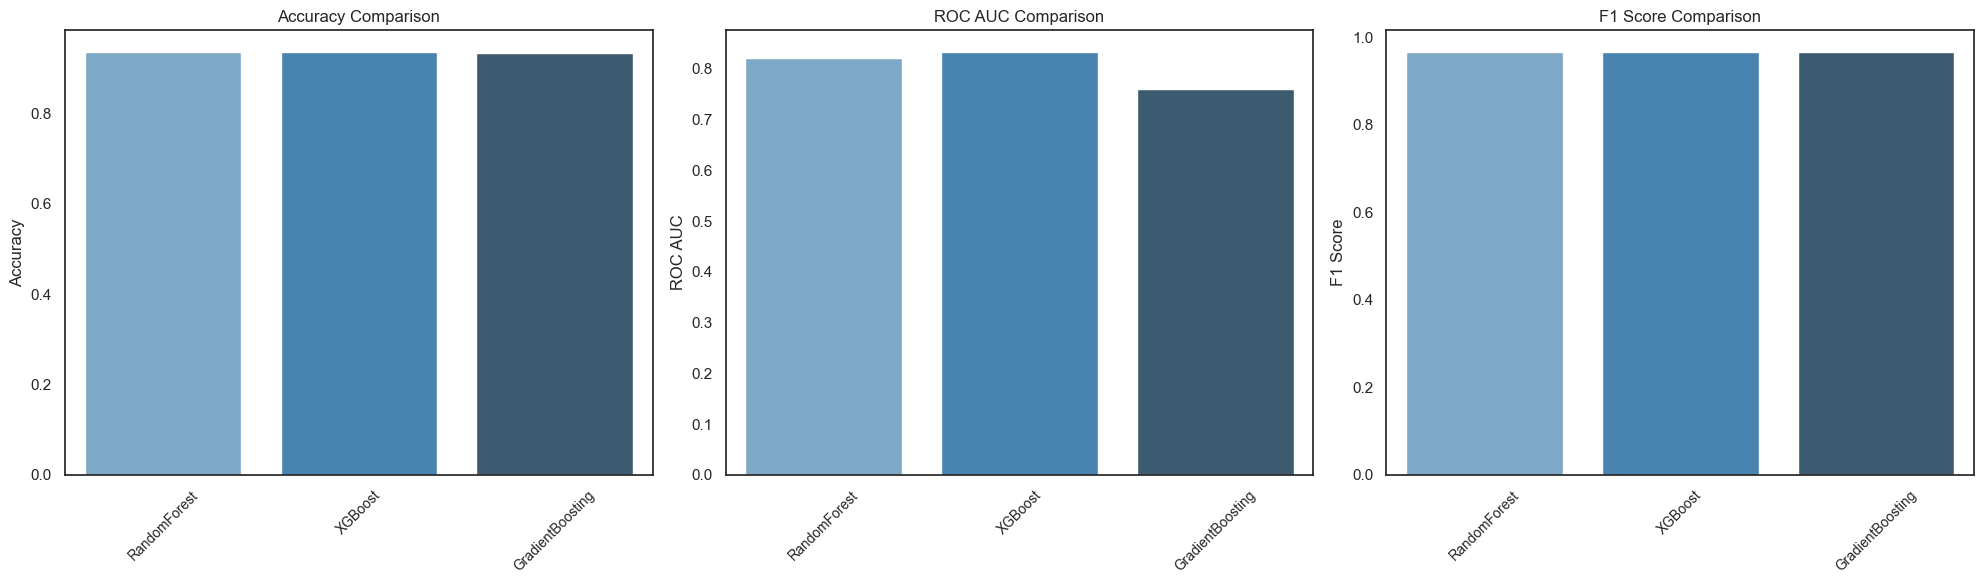

In [11]:
def compare_ml_models(rnd_accuracy, xgboodt_accuracy, gboost_accuracy,
                      roc_auc_rnd, roc_auc_xgb, roc_auc_gb,
                      f1_score_rf, f1_score_xgb, f1_score_gb,
                      rnd_average_cv_score, xgb_avg_cv_score, gb_avg_cv_score):

    model_metrics = {
        'Model': ['RandomForest', 'XGBoost', 'GradientBoosting'],
        'Accuracy': [rnd_accuracy, xgboodt_accuracy, gboost_accuracy],
        'ROC AUC': [roc_auc_rnd, roc_auc_xgb, roc_auc_gb],
        'F1 Score': [f1_score_rf, f1_score_xgb, f1_score_gb],
        'Cross-Validation Score': [rnd_average_cv_score, xgb_avg_cv_score, gb_avg_cv_score]
    }

    summary_df = pd.DataFrame(model_metrics)

    sns.set_theme(style="white", rc={"axes.grid": False})

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Create a bar plot for Accuracy
    sns.barplot(x='Model', y='Accuracy', data=summary_df, ax=axes[0], hue='Model', palette="Blues_d", legend=False)
    axes[0].set_title('Accuracy Comparison')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Accuracy')
    axes[0].tick_params(axis='x', rotation=45, labelsize=10)

    # Create a bar plot for ROC AUC
    sns.barplot(x='Model', y='ROC AUC', data=summary_df, ax=axes[1], hue='Model', palette="Blues_d", legend=False)
    axes[1].set_title('ROC AUC Comparison')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('ROC AUC')
    axes[1].tick_params(axis='x', rotation=45, labelsize=10)

    # Create a bar plot for F1 Score
    sns.barplot(x='Model', y='F1 Score', data=summary_df, ax=axes[2], hue='Model', palette="Blues_d", legend=False)
    axes[2].set_title('F1 Score Comparison')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('F1 Score')
    axes[2].tick_params(axis='x', rotation=45, labelsize=10)

    plt.tight_layout()
    plt.savefig('model_comparison.png', bbox_inches='tight', dpi=300)
    plt.show()

compare_ml_models(rf_accuracy, xgb_accuracy, gb_accuracy,
                  rf_roc_auc, xgb_roc_auc, gb_roc_auc,
                  rf_f1_score, xgb_f1_score, gb_f1_score,
                  rf_avg_cv_score, xgb_avg_cv_score, gb_avg_cv_score)
